Three models
- Normal
- Normal with regularization term and the output layer (the best).
- More complicated network to increase train accuracy.

In [1]:
## import some dependencies
## import some dependencies
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
# Load the data
data_train = pd.read_csv('Data/Water_Train_Data.txt', sep='\t')
data_cv = pd.read_csv('Data/Water_CV_Data.txt', sep='\t')
data_test = pd.read_csv('Data/Water_Test_Data.txt', sep='\t')

X_train = data_train.drop('is_safe', axis=1)
X_cv = data_cv.drop('is_safe', axis=1)
X_test = data_test.drop('is_safe', axis=1)

y_train = data_train['is_safe']
y_cv = data_cv['is_safe']
y_test = data_test['is_safe']

In [3]:
# Define the model
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # sigmoid because binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/Applications/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_cv, y_cv))

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 507us/step - accuracy: 0.8033 - loss: 0.5347 - val_accuracy: 0.8806 - val_loss: 0.2898
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - accuracy: 0.8818 - loss: 0.3004 - val_accuracy: 0.8869 - val_loss: 0.2705
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step - accuracy: 0.8999 - loss: 0.2570 - val_accuracy: 0.8875 - val_loss: 0.2602
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - accuracy: 0.8927 - loss: 0.2618 - val_accuracy: 0.8925 - val_loss: 0.2622
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - accuracy: 0.9048 - loss: 0.2335 - val_accuracy: 0.9044 - val_loss: 0.2539
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step - accuracy: 0.9026 - loss: 0.2463 - val_accuracy: 0.9056 - val_loss: 0.2350
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - accuracy: 0.9133 - loss: 0.2229 - val_accuracy: 0.9125 - val_loss: 0.2258
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - accuracy: 0.9067 - loss: 0

In [5]:
cv_loss, cv_accuracy = model.evaluate(X_cv, y_cv)
print(f"Cross-validation accuracy: {cv_accuracy:.4f}")
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.9196 - loss: 0.2325
Cross-validation accuracy: 0.9281
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.9186 - loss: 0.2135
Test accuracy: 0.9269


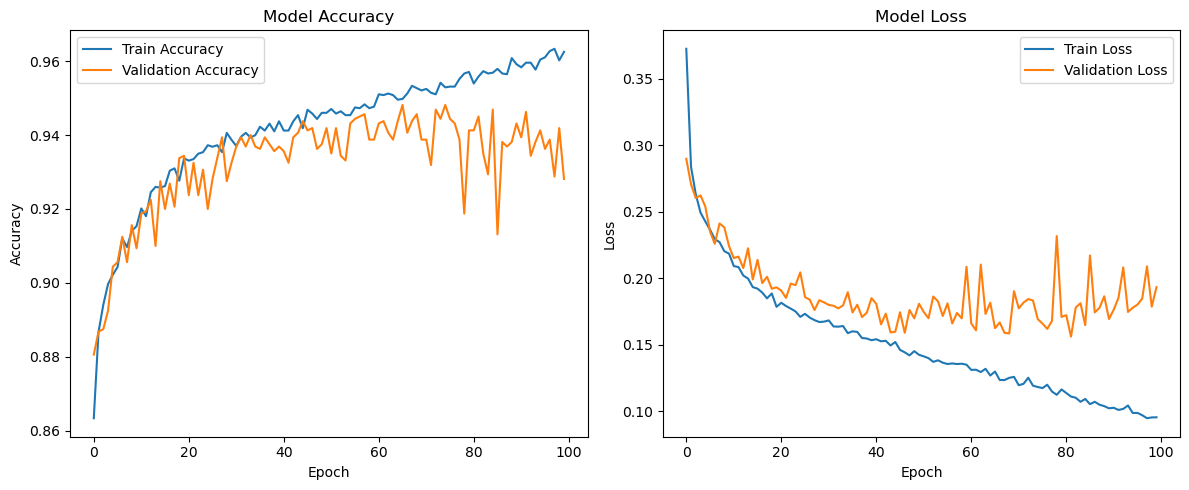

In [6]:
# Plot training & validation accuracy values
plt.figure(figsize=(12,5))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
from tensorflow.keras.regularizers import l2

# Define the model with regularization
model_regularized = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(0.1))  # sigmoid because binary classification
])

# Compile the model
model_regularized.compile(optimizer='adam',
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

/Applications/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Train the model
history_regularized = model_regularized.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_cv, y_cv))

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 514us/step - accuracy: 0.8754 - loss: 0.5539 - val_accuracy: 0.8838 - val_loss: 0.3732
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.8904 - loss: 0.3503 - val_accuracy: 0.8869 - val_loss: 0.3207
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.9044 - loss: 0.2904 - val_accuracy: 0.8913 - val_loss: 0.2915
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - accuracy: 0.8963 - loss: 0.2898 - val_accuracy: 0.8944 - val_loss: 0.2781
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - accuracy: 0.8965 - loss: 0.2828 - val_accuracy: 0.8969 - val_loss: 0.2690
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - accuracy: 0.9008 - loss: 0.2795 - val_accuracy: 0.8981 - val_loss: 0.2725
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - accuracy: 0.9027 - loss: 0.2587 - val_accuracy: 0.9025 - val_loss: 0.2578
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - accuracy: 0.9073 - loss: 0

In [17]:
cv_loss_regularized, cv_accuracy_regularized = model_regularized.evaluate(X_cv, y_cv)
print(f"Cross-validation accuracy (regularized): {cv_accuracy_regularized:.4f}")
test_loss_regularized, test_accuracy_regularized = model_regularized.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy_regularized:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.9328 - loss: 0.1849
Cross-validation accuracy (regularized): 0.9494
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - accuracy: 0.9305 - loss: 0.1972
Test accuracy: 0.9444


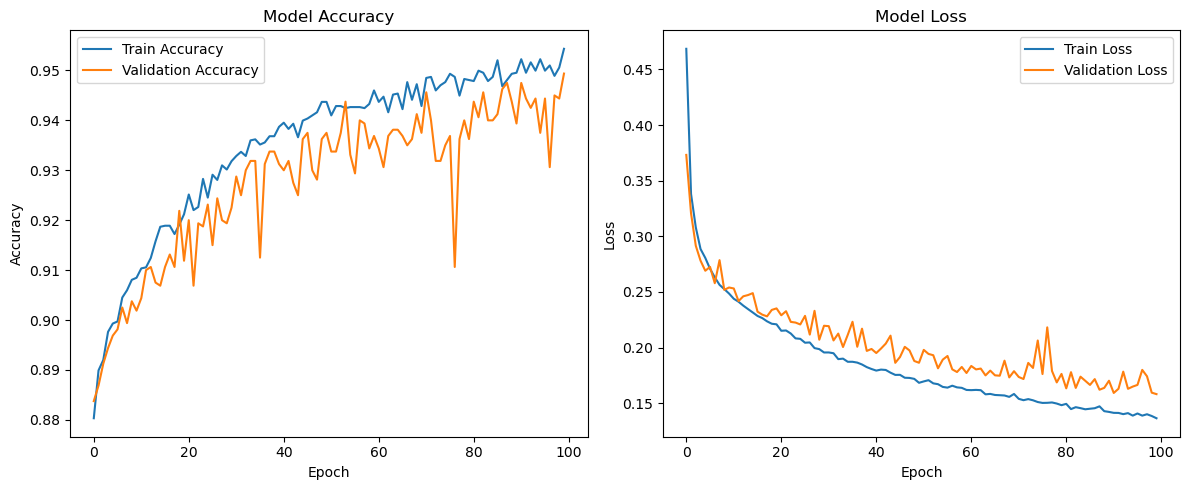

In [19]:
# Plot training & validation accuracy values
plt.figure(figsize=(12,5))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history_regularized.history['accuracy'], label='Train Accuracy')
plt.plot(history_regularized.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history_regularized.history['loss'], label='Train Loss')
plt.plot(history_regularized.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Define the model with regularization
from tensorflow.keras.layers import Dropout

model_regularized_droupout = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu', kernel_regularizer=l2(1.0)),
    layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(10.0))
])
# Compile the model
model_regularized_droupout.compile(optimizer='adam',
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

/Applications/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
history_regularized_droupout = model_regularized_droupout.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_cv, y_cv))

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step - accuracy: 0.8679 - loss: 8.9897 - val_accuracy: 0.8844 - val_loss: 1.3681
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.8842 - loss: 0.9321 - val_accuracy: 0.8844 - val_loss: 0.3819
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.8774 - loss: 0.3735 - val_accuracy: 0.8844 - val_loss: 0.3203
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.8898 - loss: 0.3066 - val_accuracy: 0.8844 - val_loss: 0.2990
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - accuracy: 0.8815 - loss: 0.3003 - val_accuracy: 0.8844 - val_loss: 0.2850
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.8895 - loss: 0.2732 - val_accuracy: 0.8844 - val_loss: 0.3065
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - accuracy: 0.8854 - loss: 0.2719 - val_accuracy: 0.8844 - val_loss: 0.2724
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.8819 - loss: 0

In [13]:
cv_loss_regularized_droupout, cv_accuracy_regularized_droupout = model_regularized_droupout.evaluate(X_cv, y_cv)
print(f"Cross-validation accuracy (regularized): {cv_accuracy_regularized_droupout:.4f}")
test_loss_regularized_droupout, test_accuracy_regularized_droupout = model_regularized_droupout.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy_regularized_droupout:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.9359 - loss: 0.1963
Cross-validation accuracy (regularized): 0.9475
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.9280 - loss: 0.1903
Test accuracy: 0.9394


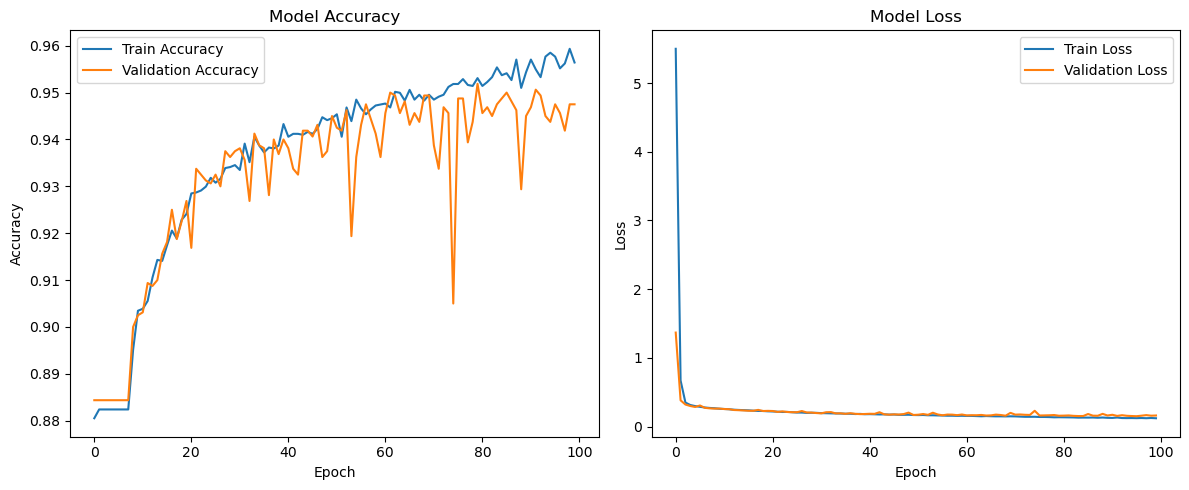

In [14]:
# Plot training & validation accuracy values
plt.figure(figsize=(12,5))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history_regularized_droupout.history['accuracy'], label='Train Accuracy')
plt.plot(history_regularized_droupout.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history_regularized_droupout.history['loss'], label='Train Loss')
plt.plot(history_regularized_droupout.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()